# Day 3 - Bias-Variance & Diagnosing Model Fit

## Introduction

A model can perform poorly for different reasons.

Sometimes it is too simple to learn the important patterns, and sometimes it learns the training data too closely.

In this notebook, I will use the stroke dataset to compare these cases and see how changing the Decision Tree depth affects the training and validation F1-scores.

## Topics

- Underfitting and overfitting
- Bias-variance trade-off
- Train-validation gap
- Reducing model complexity
- Model comparison

## Import Libraries

In [104]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import f1_score

# Lesson Content

## 3.1 - Underfitting and Overfitting

There are two common ways a model can fail.

### Underfitting - High Bias

Underfitting happens when the model is too simple to learn the patterns in the data.

Common signs:

- Low training score
- Low validation score
- Small train-validation gap

A possible fix is to increase the model complexity.

### Overfitting - High Variance

Overfitting happens when the model learns the training data too closely.

Common signs:

- High training score
- Much lower validation score
- Large train-validation gap

Possible fixes include reducing model complexity or using regularization.

The difference between these two cases can be understood through the **bias-variance trade-off**, which explains how model complexity affects performance.

**Applied in Hands-On:** Step 1 (Overfitting) and Step 2 (Underfitting).

## 3.2 - Bias-Variance Trade-off

Underfitting is usually related to high bias, while overfitting is related to high variance.

- Simple model → Higher bias
- Complex model → Higher variance

As the model becomes more complex, it may learn more patterns, but it can also start fitting the training data too closely.

The goal is to find a balance between the two.

**Applied in Hands-On:** Step 3, where different tree depths are compared.

## 3.3 - How to Diagnose Model Fit

The training and validation scores can help identify the problem.

| Training Score | Validation Score | Diagnosis |
|---|---|---|
| Low | Low | Underfitting |
| High | Much lower | Overfitting |
| High | High and close | Good Fit |

The gap should not be checked alone. Both scores also need to be considered.

**Applied in Hands-On:** Step 4, where the models are compared using their training and validation F1-scores.

## 3.4 - Reducing Overfitting

One way to reduce overfitting is to make the model less complex.

For a Decision Tree, this can be done by limiting its depth.

Regularization is another method used with models such as Ridge and Lasso:

- **Ridge (L2):** reduces the size of the coefficients.
- **Lasso (L1):** can reduce some coefficients to zero.
- A larger `alpha` means stronger regularization.

In the hands-on part, I will reduce the Decision Tree depth and check how the train-validation gap changes.

**Applied in Hands-On:** Step 3, where the Decision Tree depth is reduced to control model complexity.

In [121]:

ridge = Ridge(alpha=1.0)   # L2: shrinks all weights toward zero
lasso = Lasso(alpha=0.1)   # L1: can zero out weak features entirely



Ridge uses L2 regularization and Lasso uses L1 regularization.
A larger alpha applies a stronger penalty and makes the model simpler.

# Hands-On Lab

In this lab, I will deliberately create models with different levels of complexity.

The goal is to compare their training and validation performance and diagnose whether each model is underfitting, overfitting, or fitting the data better.

In [106]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df = df.drop("id", axis=1)

x = df.drop("stroke", axis=1)
y = df["stroke"]



### Observation

The dataset was loaded successfully.

The `id` column was removed because it does not help the model predict stroke.

The remaining patient features are stored in `x`, while `stroke` is stored in `y`.

In [107]:
x_train, x_val, y_train, y_val = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Observation

I split the data first so the validation set is not used when calculating the BMI mean.

### Prepare the Features

The `bmi` column contains missing values, and some features are categorical.

I will fill the missing BMI values and convert the categorical features into numerical values before training the Decision Tree models.

In [108]:
bmi_mean = x_train["bmi"].mean()

x_train = x_train.copy()
x_val = x_val.copy()

x_train["bmi"] = x_train["bmi"].fillna(bmi_mean)
x_val["bmi"] = x_val["bmi"].fillna(bmi_mean)

### Observation

The missing BMI values were filled using the mean calculated from the training data only.

The same training mean was used for the validation set to avoid data leakage.

In [109]:
x_train = pd.get_dummies(x_train, drop_first=True)
x_val = pd.get_dummies(x_val, drop_first=True)

x_train, x_val = x_train.align(
    x_val,
    join="left",
    axis=1,
    fill_value=0
)

### Observation

The categorical features were converted into numerical values.

The training and validation sets were aligned so they contain the same 16 features.

In [110]:
print("Training set:", x_train.shape)
print("Validation set:", x_val.shape)

Training set: (4088, 16)
Validation set: (1022, 16)


### Observation

After preprocessing, the training set contains 4088 samples and the validation set contains 1022 samples.

Both sets have the same 16 features, so they are ready for the model experiments.

### Why Compare Training and Validation Scores?

The training score shows how the model performs on data it already saw.

The validation score shows how it performs on unseen data.

The difference between them helps me tell if the model is underfitting or overfitting.

## Step 1 - Deliberately Overfit a Model

To see what overfitting looks like, I will train a Decision Tree without limiting its depth.

A very deep tree can learn the training data too closely, so I expect the training score to be much higher than the validation score.

In [111]:
overfit_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

overfit_tree.fit(x_train, y_train)

train_pred = overfit_tree.predict(x_train)
val_pred = overfit_tree.predict(x_val)

train_f1 = f1_score(y_train, train_pred)
val_f1 = f1_score(y_val, val_pred)

print("Training F1-score:", train_f1)
print("Validation F1-score:", val_f1)
print("Gap:", train_f1 - val_f1)

Training F1-score: 1.0
Validation F1-score: 0.17857142857142858
Gap: 0.8214285714285714



### Observation

The training F1-score is 1.000, while the validation F1-score is only 0.179.

The large gap between them shows clear overfitting.

## Step 2 - Deliberately Underfit a Model

Now I will do the opposite and make the Decision Tree very simple by limiting its depth to 1.

If the model is too simple, I expect both the training and validation F1-scores to be low.

In [112]:
underfit_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

underfit_tree.fit(x_train, y_train)

train_pred_u = underfit_tree.predict(x_train)
val_pred_u = underfit_tree.predict(x_val)

train_f1_u = f1_score(y_train, train_pred_u)
val_f1_u = f1_score(y_val, val_pred_u)

print("Training F1-score:", train_f1_u)
print("Validation F1-score:", val_f1_u)
print("Gap:", train_f1_u - val_f1_u)

Training F1-score: 0.0
Validation F1-score: 0.0
Gap: 0.0


### Observation

Both the training and validation F1-scores are 0.0.

The model is too simple to detect the stroke class, so it performs poorly on both datasets.

This is a clear case of underfitting.

## Step 3 - Reduce Model Complexity

The unrestricted Decision Tree clearly overfit the training data.

To reduce overfitting, I will limit the tree depth and compare the new training and validation F1-scores.


### First Attempt to Reduce Complexity

In [122]:
fixed_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

fixed_tree.fit(x_train, y_train);

### Observation

The new tree is limited to a depth of 4.

This makes the model less complex than the unrestricted tree.

### Check The New Model Performance 
I will now compaare the training and validation F1-score after reducing the tree depth 

In [114]:
fixed_train_pred = fixed_tree.predict(x_train)
fixed_val_pred = fixed_tree.predict(x_val)

fixed_train_f1 = f1_score(y_train, fixed_train_pred)
fixed_val_f1 = f1_score(y_val, fixed_val_pred)

fixed_gap = fixed_train_f1 - fixed_val_f1

In [115]:
print("Training F1-score:", fixed_train_f1)
print("Validation F1-score:", fixed_val_f1)
print("Gap:", fixed_gap)

Training F1-score: 0.07692307692307693
Validation F1-score: 0.0
Gap: 0.07692307692307693


Observation

After limiting the tree depth to 4, the training F1-score dropped to 0.077, while the validation F1-score reached 0.0. Although the gap became smaller, the model could no longer detect stroke cases effectively, which means it became too simple and started underfitting.

### Try Different Tree Depths

Depth 4 became too simple, so I will try several depths and compare their F1-scores.

In [116]:
depth_results = []

for depth in range(2, 11):

    # Build and train the tree
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(x_train, y_train)

    # Calculate F1-scores
    train_f1_d = f1_score(
        y_train,
        tree.predict(x_train)
    )

    val_f1_d = f1_score(
        y_val,
        tree.predict(x_val)
    )

    # Save the results
    depth_results.append({
        "Depth": depth,
        "Train F1": train_f1_d,
        "Validation F1": val_f1_d,
        "Gap": train_f1_d - val_f1_d
    })

### Observation

Several tree depths were tested using the same training and validation data.

The next step is to put the results in a table so I can see which depth gives a better balance.

In [117]:
depth_results_df = pd.DataFrame(depth_results)

depth_results_df

,Depth,Train F1,Validation F1,Gap
0,2,0.029703,0.000000,0.029703
1,3,0.029703,0.000000,0.029703
2,4,0.076923,0.000000,0.076923
3,5,0.086538,0.000000,0.086538
4,6,0.163636,0.000000,0.163636
5,7,0.358209,0.061538,0.296670
6,8,0.446097,0.085714,0.360382
7,9,0.492424,0.083333,0.409091
8,10,0.613333,0.117647,0.495686


### Observation

- For very small tree depths, the validation F1-score stayed at 0, which means the model was too simple to detect stroke cases.

- As the depth increased, the validation F1-score started to improve, but the gap between training and validation also became larger.

- Depth 10 gave the highest validation F1-score in this range, so I will use it in the final comparison.

### Tree Depth Comparison

I plotted the training and validation F1-scores to see how they change with tree depth.

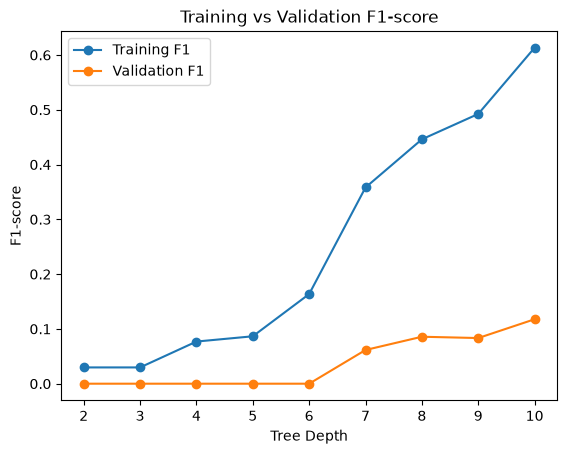

In [118]:
plt.plot(
    depth_results_df["Depth"],
    depth_results_df["Train F1"],
    marker="o",
    label="Training F1"
)

plt.plot(
    depth_results_df["Depth"],
    depth_results_df["Validation F1"],
    marker="o",
    label="Validation F1"
)

plt.xlabel("Tree Depth")
plt.ylabel("F1-score")
plt.title("Training vs Validation F1-score")
plt.legend()

plt.show()

### Observation

For depths 2 to 6, the validation F1-score stayed at 0.

From depth 7, the validation score started to improve, but the training score increased much faster.

This shows that deeper trees improve training performance, but the gap also becomes larger.

## Step 4 - Final Diagnosis

Now I will compare the underfitting model, the overfitting model, and the reduced-complexity tree.

In [119]:
depth10 = depth_results_df.iloc[-1]

comparison = pd.DataFrame({
    "Model": ["Underfit", "Overfit", "Depth 10"],
    "Train F1": [train_f1_u, train_f1, depth10["Train F1"]],
    "Validation F1": [val_f1_u, val_f1, depth10["Validation F1"]]
})

comparison

,Model,Train F1,Validation F1
0,Underfit,0.000000,0.000000
1,Overfit,1.000000,0.178571
2,Depth 10,0.613333,0.117647


### Observation

The underfit tree performed poorly on both training and validation data.

The unrestricted tree achieved a perfect training F1-score, but its validation score was much lower, showing overfitting.

After limiting the tree depth, the training score decreased, but the validation score also stayed low. This shows that reducing complexity alone did not fully solve the problem.

### Model Comparison

I will compare the training and validation F1-scores for the three cases.

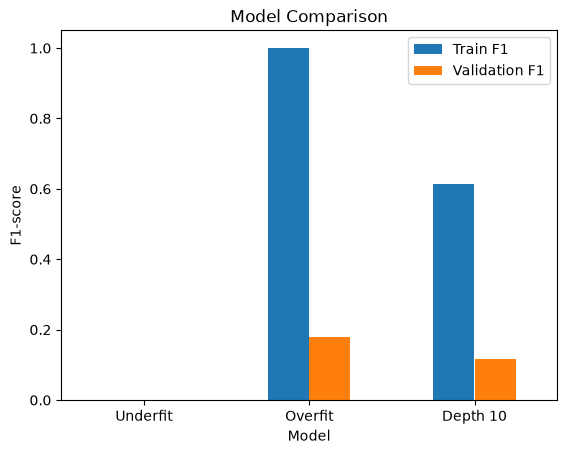

In [120]:
comparison.plot(
    x="Model",
    y=["Train F1", "Validation F1"],
    kind="bar"
)

plt.ylabel("F1-score")
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

### Observation

 - The underfit model got 0.000 for both training and validation.

- The overfit model got 1.000 on training and 0.179 on validation.

- At depth 10, the training score became 0.613 and the validation score was 0.118.

- So the gap became smaller, but the validation score was still low.

### Before and After Reducing Complexity

**Before**
- Training F1 = 1.000
- Validation F1 = 0.179

**Depth 10**
- Training F1 = 0.613
- Validation F1 = 0.118

The gap became smaller after reducing the tree depth, but the validation score was still low.

### Final Diagnosis

- The depth 1 tree underfit the data with 0.000 F1 on both training and validation.
- The unrestricted tree overfit with 1.000 training F1 and 0.179 validation F1.
- Depth 10 gave 0.613 training F1 and 0.118 validation F1.
- The gap decreased from 0.821 to about 0.496 after reducing the tree depth.
- The validation score was still low, so the model did not reach a good fit.

A smaller train-validation gap does not always mean a better model if both scores are still low.